# BCI2000 Signal Explorer

This notebook explores the **continuous signal data** stored in a BCI2000 `.dat` file.

It intentionally does **not** analyze BCI2000 states.

The notebook will:

- open the `.dat` recording
- report the number of channels, samples, sampling rate, and duration
- decode the continuous signal
- inspect signal shape and numeric range
- summarize every channel
- plot a short multichannel segment
- inspect one channel in detail
- calculate a simple frequency spectrum for one channel

The signal is kept separate from behavioral/task state information.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from BCI2000Tools.FileReader import bcistream

pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 140)


## 1. Select the BCI2000 `.dat` file


In [2]:
# Change this path to the recording you want to explore.

DAT_PATH = Path(
    r"C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat"
)

if not DAT_PATH.is_file():
    raise FileNotFoundError(
        f"File not found: {DAT_PATH}\n"
        "Edit DAT_PATH above so it points to the correct BCI2000 .dat file."
    )

print(f"Using: {DAT_PATH.resolve()}")


Using: C:\Users\gabri\Desktop\joystick_test_env\python_da\patient_data\ECOGS001R02.dat


## 2. Open the file and inspect recording metadata

This information comes from the BCI2000 recording itself.

The signal has one value for every **channel × sample** combination.
At a sampling rate of 2000 Hz, each channel has 2000 measurements per second.


In [3]:
stream = bcistream(str(DAT_PATH))

n_channels = int(stream.nchan)
n_samples = int(stream.samples())
fs = float(stream.samplingfreq_hz)
duration_s = n_samples / fs

print(f"Channels:       {n_channels:,}")
print(f"Samples:        {n_samples:,}")
print(f"Sampling rate:  {fs:g} Hz")
print(f"Duration:       {duration_s:.2f} seconds")
print(f"Duration:       {duration_s / 60:.2f} minutes")
print(f"Signal values:  {n_channels * n_samples:,}")


Channels:       256
Samples:        1,255,100
Sampling rate:  2000 Hz
Duration:       627.55 seconds
Duration:       10.46 minutes
Signal values:  321,305,600


## 3. Decode the continuous signal

`bcistream.decode()` returns the signal separately from the states.

This notebook keeps only the signal.

Because BCI2000Tools versions can differ in array orientation, the code below automatically converts the signal into the consistent form:

```text
samples × channels
```

So:

```text
signal[sample_number, channel_number]
```

always refers to one signal measurement.


In [4]:
# Request no state variables because this notebook is focused on signal data.
# Some BCI2000Tools versions may not accept an empty state list, so a
# compatibility fallback is included.

try:
    signal_raw, _ = stream.decode(
        nsamp="all",
        states=[],
    )
except Exception:
    signal_raw, _ = stream.decode(
        nsamp="all",
    )

signal_raw = np.asarray(signal_raw)

print("Raw decoded shape:", signal_raw.shape)
print("Raw dtype:", signal_raw.dtype)

# Normalize orientation to: samples × channels
if signal_raw.shape == (n_channels, n_samples):
    signal = signal_raw.T
elif signal_raw.shape == (n_samples, n_channels):
    signal = signal_raw
else:
    raise ValueError(
        "Unexpected signal shape. "
        f"Expected {(n_channels, n_samples)} or {(n_samples, n_channels)}, "
        f"but received {signal_raw.shape}."
    )

print("Normalized shape:", signal.shape)
print("Interpretation:     samples × channels")


Raw decoded shape: (256, 1255100)
Raw dtype: float32
Normalized shape: (1255100, 256)
Interpretation:     samples × channels


## 4. Look directly at the signal matrix

Each row is one time sample.

Each column is one recorded channel.

Only a tiny piece is displayed because the complete recording may contain hundreds of millions of values.


In [5]:
N_ROWS_TO_SHOW = 10
N_CHANNELS_TO_SHOW = min(10, n_channels)

signal_preview = pd.DataFrame(
    signal[:N_ROWS_TO_SHOW, :N_CHANNELS_TO_SHOW],
    columns=[f"Ch{i + 1}" for i in range(N_CHANNELS_TO_SHOW)],
)

signal_preview.index.name = "sample"

display(signal_preview)


,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8,Ch9,Ch10
sample,,,,,,,,,,
0,-2.050781,-103.515625,-48.925781,-14.453125,12.500000,20.703125,23.144531,144.433594,83.691406,92.773438
1,3.613281,-97.363281,-44.824219,-9.667969,12.402344,21.191406,28.320312,148.632812,88.574219,97.167969
2,9.277344,-90.820312,-39.257812,-5.273438,12.792969,20.800781,34.179688,152.734375,92.578125,101.367188
3,13.476562,-86.425781,-35.742188,-2.343750,13.671875,19.824219,38.183594,156.152344,95.507812,104.394531
4,11.718750,-87.402344,-37.402344,-4.199219,14.160156,18.652344,38.671875,154.882812,94.824219,104.003906
5,6.738281,-92.089844,-41.992188,-8.691406,15.039062,17.773438,37.402344,150.683594,91.992188,100.976562
6,7.421875,-90.820312,-40.332031,-5.566406,15.429688,17.089844,41.210938,151.660156,93.652344,102.734375
7,12.597656,-84.863281,-34.960938,1.464844,16.015625,16.992188,47.851562,157.226562,99.218750,108.496094
8,17.871094,-79.589844,-29.589844,6.835938,16.406250,16.796875,52.734375,162.109375,104.394531,112.988281


## 5. Summarize every signal channel

This gives a basic quality-control view of the continuous recording.

For each channel it calculates:

- minimum
- maximum
- mean
- standard deviation
- RMS amplitude

Large differences between channels can help identify channels that deserve closer inspection.


In [6]:
channel_summary = pd.DataFrame({
    "channel": np.arange(1, n_channels + 1),
    "min": np.nanmin(signal, axis=0),
    "max": np.nanmax(signal, axis=0),
    "mean": np.nanmean(signal, axis=0),
    "std": np.nanstd(signal, axis=0),
    "rms": np.sqrt(np.nanmean(np.square(signal.astype(np.float64)), axis=0)),
})

channel_summary = channel_summary.set_index("channel")

display(channel_summary)


,min,max,mean,std,rms
channel,,,,,
1,-661.914062,1332.226562,23.760223,157.488846,159.271095
2,-687.500000,1184.375000,14.535195,169.441360,170.063653
3,-693.066406,1023.437500,26.121801,157.887253,160.033532
4,-625.097656,1012.890625,5.549299,148.573318,148.676916
5,-40.917969,151.855469,17.580160,11.406258,20.956258
6,-119.140625,74.218750,15.499125,11.523135,19.313350
7,-586.816406,1041.406250,24.184868,167.571701,169.307960
8,-586.035156,477.441406,13.030819,111.627472,112.385459
9,-535.839844,370.703125,9.622890,90.679192,91.188355


## 6. Plot a short segment from several channels

Plotting the entire recording at once usually hides the waveform structure.

Change `START_TIME_S`, `WINDOW_S`, and `CHANNELS_TO_PLOT` to inspect different portions of the recording.

Channel numbers here are **1-based**, matching how channels are normally discussed.


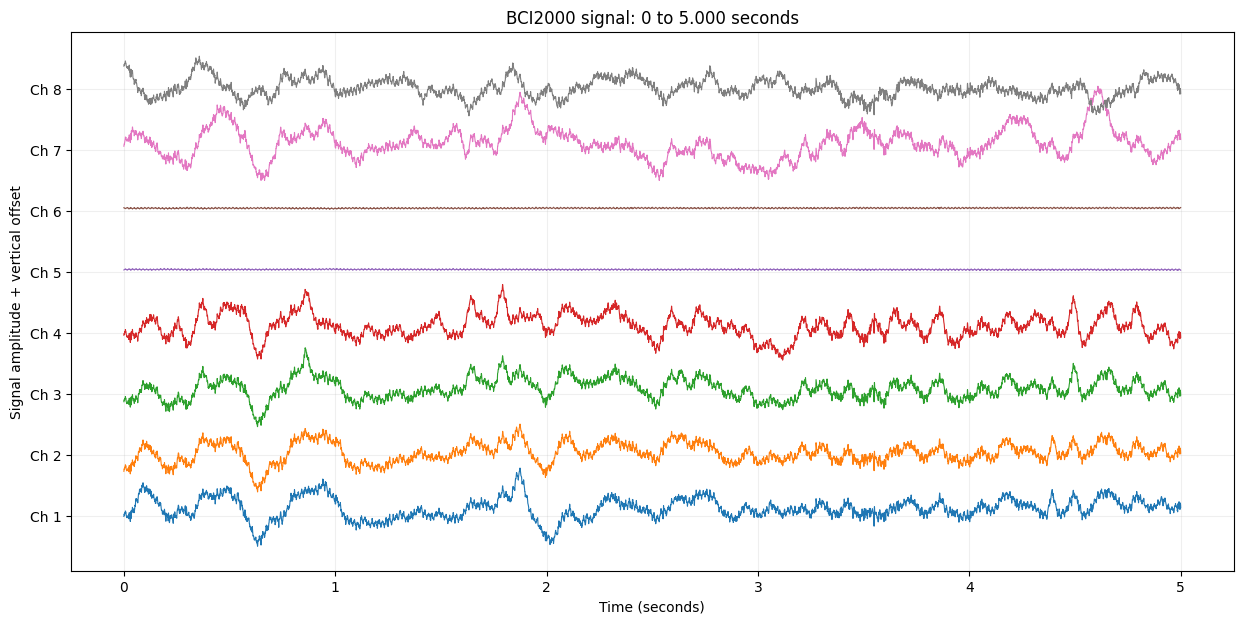

In [7]:
START_TIME_S = 0
WINDOW_S = 5
CHANNELS_TO_PLOT = list(range(1, min(8, n_channels) + 1))

start_sample = int(START_TIME_S * fs)
stop_sample = min(int((START_TIME_S + WINDOW_S) * fs), n_samples)

if start_sample >= n_samples:
    raise ValueError("START_TIME_S is beyond the end of the recording.")

sample_indices = np.arange(start_sample, stop_sample)
time_s = sample_indices / fs

fig, ax = plt.subplots(figsize=(15, 7))

# Offset traces vertically so they do not overlap.
segment = signal[start_sample:stop_sample, np.array(CHANNELS_TO_PLOT) - 1]
channel_scale = np.nanmedian(np.nanstd(segment, axis=0))

if not np.isfinite(channel_scale) or channel_scale == 0:
    channel_scale = 1.0

offset_step = channel_scale * 6

for i, channel_number in enumerate(CHANNELS_TO_PLOT):
    trace = signal[start_sample:stop_sample, channel_number - 1]
    ax.plot(time_s, trace + i * offset_step, linewidth=0.8)

ax.set_title(
    f"BCI2000 signal: {START_TIME_S:g} to "
    f"{stop_sample / fs:.3f} seconds"
)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Signal amplitude + vertical offset")
ax.set_yticks(
    np.arange(len(CHANNELS_TO_PLOT)) * offset_step,
    [f"Ch {ch}" for ch in CHANNELS_TO_PLOT],
)
ax.grid(alpha=0.2)

plt.show()


## 7. Deep dive into one signal channel

Change `CHANNEL_TO_VIEW` to inspect another channel.

This cell shows:

- number of samples
- minimum
- maximum
- mean
- standard deviation
- a waveform segment


Channel: 1
Samples: 1,255,100
Min:     -661.914
Max:     1332.23
Mean:    23.7602
Std:     157.489


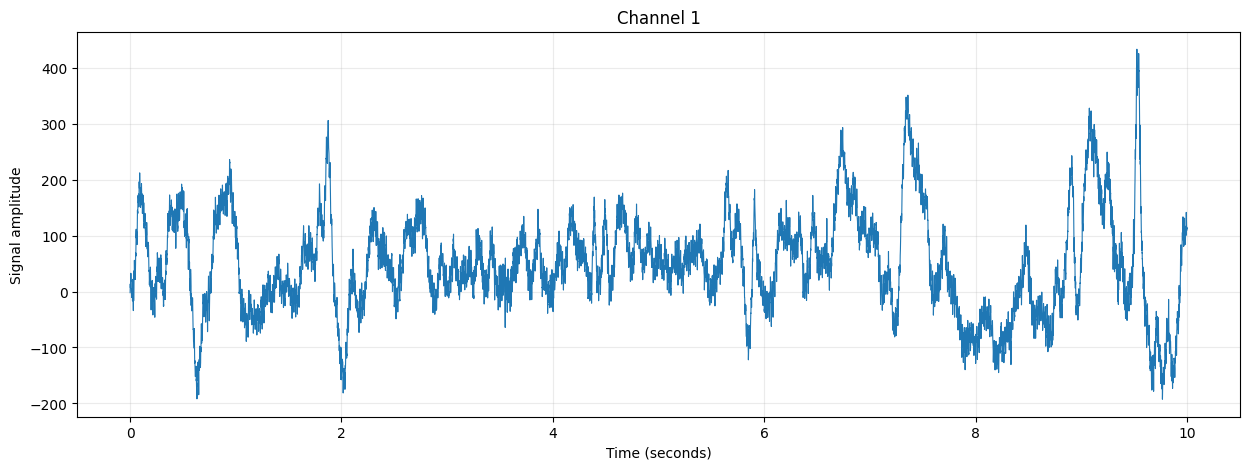

In [8]:
CHANNEL_TO_VIEW = 1
START_TIME_S = 0
WINDOW_S = 10

if not 1 <= CHANNEL_TO_VIEW <= n_channels:
    raise ValueError(
        f"CHANNEL_TO_VIEW must be between 1 and {n_channels}."
    )

channel_index = CHANNEL_TO_VIEW - 1
channel = signal[:, channel_index]

print(f"Channel: {CHANNEL_TO_VIEW}")
print(f"Samples: {channel.size:,}")
print(f"Min:     {np.nanmin(channel):.6g}")
print(f"Max:     {np.nanmax(channel):.6g}")
print(f"Mean:    {np.nanmean(channel):.6g}")
print(f"Std:     {np.nanstd(channel):.6g}")

start_sample = int(START_TIME_S * fs)
stop_sample = min(int((START_TIME_S + WINDOW_S) * fs), n_samples)

time_s = np.arange(start_sample, stop_sample) / fs

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    time_s,
    channel[start_sample:stop_sample],
    linewidth=0.8,
)

ax.set_title(f"Channel {CHANNEL_TO_VIEW}")
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Signal amplitude")
ax.grid(alpha=0.25)

plt.show()


## 8. Frequency spectrum of one channel

A neural signal is a time-domain waveform, but it can also be described by how much amplitude is present at different frequencies.

This cell uses an FFT on a selected time window.

It is meant as a **basic explorer**, not a finished spectral-analysis pipeline. No filtering, rereferencing, artifact rejection, or line-noise removal is applied here.


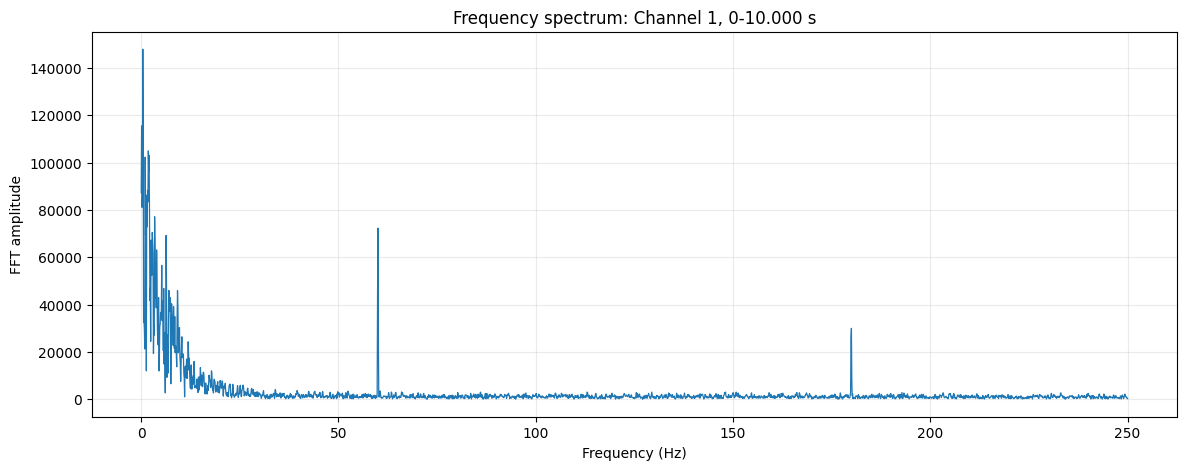

In [9]:
CHANNEL_TO_VIEW = 1
START_TIME_S = 0
WINDOW_S = 10
MAX_FREQUENCY_HZ = min(250, fs / 2)

channel_index = CHANNEL_TO_VIEW - 1
start_sample = int(START_TIME_S * fs)
stop_sample = min(int((START_TIME_S + WINDOW_S) * fs), n_samples)

x = signal[start_sample:stop_sample, channel_index].astype(np.float64)

if x.size < 2:
    raise ValueError("The selected spectrum window is too short.")

# Remove the mean so the zero-frequency/DC component does not dominate.
x = x - np.nanmean(x)

# Replace any remaining NaNs so FFT can run.
x = np.nan_to_num(x)

window = np.hanning(x.size)
x_windowed = x * window

fft_values = np.fft.rfft(x_windowed)
frequencies = np.fft.rfftfreq(x.size, d=1 / fs)

# Simple amplitude spectrum.
amplitude = np.abs(fft_values)

mask = frequencies <= MAX_FREQUENCY_HZ

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    frequencies[mask],
    amplitude[mask],
    linewidth=0.9,
)

ax.set_title(
    f"Frequency spectrum: Channel {CHANNEL_TO_VIEW}, "
    f"{START_TIME_S:g}-{stop_sample / fs:.3f} s"
)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("FFT amplitude")
ax.grid(alpha=0.25)

plt.show()


## 9. Find channels with the largest variability

This is a quick screening tool.

A very large standard deviation does **not automatically mean a bad channel**. It only tells you that the channel varies more strongly than others and may be worth inspecting.


In [10]:
N_CHANNELS = min(20, n_channels)

most_variable = (
    channel_summary
    .sort_values("std", ascending=False)
    .head(N_CHANNELS)
)

display(most_variable)


,min,max,mean,std,rms
channel,,,,,
249,-3200.000000,3199.902344,68.443611,1124.915161,1126.995439
226,-3136.718750,2900.292969,11.440184,520.504700,520.630491
223,-3200.000000,3198.437500,8.572068,441.580475,441.663674
225,-2104.687500,2425.390625,14.314163,380.684753,380.953725
245,-1486.718750,3199.902344,-0.446207,331.909943,331.910235
250,-1913.574219,3199.902344,-2.446673,273.400208,273.411095
224,-2369.140625,1999.316406,-6.480290,251.616058,251.699472
50,-770.800781,1202.929688,24.372129,218.375763,219.731623
35,-620.312500,1270.605469,12.199162,196.492111,196.870432


## What this notebook is examining

The important separation is:

```text
.dat file
│
├── continuous signal  <-- THIS NOTEBOOK
│   ├── channel 1
│   ├── channel 2
│   ├── ...
│   └── channel N
│
└── states             <-- not analyzed here
    ├── TaskCondition
    ├── TargetHit
    ├── ReactionTimeMs
    └── ...
```

The plots above are therefore generated from the **recorded signal values themselves**, rather than from task-state variables.

A later analysis can use states only as event markers to select particular portions of this signal, such as neural activity around movement onset.
